# 04 — Train Final Model
Đọc best configuration, train trên Development, kiểm tra Hold-out Validation, xem selected features, rồi train full data.

In [1]:
from pathlib import Path
import sys, numpy as np, pandas as pd
import matplotlib.pyplot as plt
cwd=Path.cwd(); ROOT=cwd.parent if cwd.name.lower()=="notebooks" else cwd
SRC_DIR=ROOT/"src"
if str(SRC_DIR) not in sys.path: sys.path.append(str(SRC_DIR))
DATA_DIR=ROOT/"data"; EXPS_DIR=ROOT/"exps"; MODELS_DIR=ROOT/"models"/"sklearn"; SUBMISSIONS_DIR=ROOT/"submissions"
print("ROOT:",ROOT)
print("train.csv:",(DATA_DIR/"train.csv").exists())

ROOT: D:\house_price
train.csv: True


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from train import load_best_configuration,build_final_pipeline
from feature_selection import get_selected_feature_names
train_df=pd.read_csv(DATA_DIR/"train.csv"); X=train_df.drop(columns=["SalePrice"]); y=train_df["SalePrice"]
model_name,k,use_fe,best=load_best_configuration()
print("Model:",model_name); print("FE:",use_fe); print("k:",k); print("CV RMSE:",best["cv_rmse_mean"])

Model: GradientBoosting
FE: True
k: all
CV RMSE: 0.125655012742581


In [3]:
X_dev,X_valid,y_dev,y_valid=train_test_split(X,y,test_size=0.2,random_state=42)
pipeline=build_final_pipeline(model_name,k,use_fe)
pipeline.fit(X_dev,np.log1p(y_dev))
print("Development training complete")

Development training complete


In [4]:
pred_log=pipeline.predict(X_valid)
rmse=np.sqrt(mean_squared_error(np.log1p(y_valid),pred_log))
print(f"Hold-out RMSE: {rmse:.5f}")
pred=np.expm1(pred_log)
comparison=pd.DataFrame({"Actual":y_valid.values,"Predicted":pred}); comparison["AbsoluteError"]=(comparison.Actual-comparison.Predicted).abs(); display(comparison.head(20))

Hold-out RMSE: 0.13731


,Actual,Predicted,AbsoluteError
0,154500,145607.765774,8892.234226
1,325000,336743.500192,11743.500192
2,115000,109980.665733,5019.334267
3,159000,142646.218197,16353.781803
4,315500,326639.808239,11139.808239
5,75500,73813.950434,1686.049566
6,311500,234176.191350,77323.808650
7,146000,143209.377237,2790.622763
8,84500,76082.666373,8417.333627
9,135500,140535.771121,5035.771121


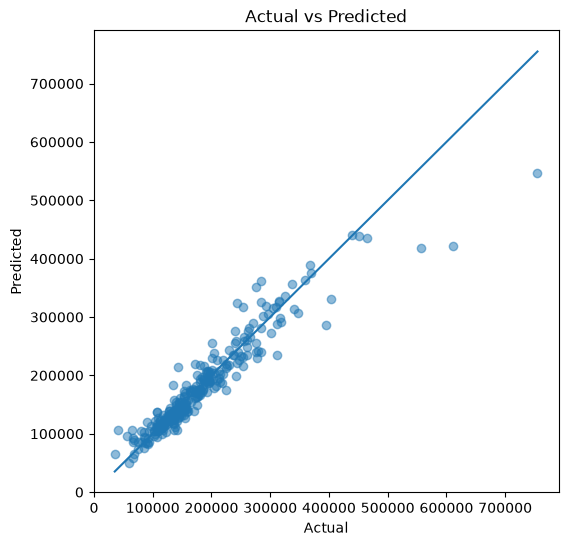

In [6]:
plt.figure(figsize=(6,6)); plt.scatter(y_valid,pred,alpha=.5); lo=min(y_valid.min(),pred.min()); hi=max(y_valid.max(),pred.max()); plt.plot([lo,hi],[lo,hi]); plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.title("Actual vs Predicted"); plt.show()

In [7]:
selected=get_selected_feature_names(pipeline)
print("Selected features:",len(selected))
print(*selected[:50],sep="\n")

Selected features: 336
LotFrontage
LotArea
OverallQual
OverallCond
YearBuilt
YearRemodAdd
MasVnrArea
BsmtFinSF1
BsmtFinSF2
BsmtUnfSF
TotalBsmtSF
1stFlrSF
2ndFlrSF
LowQualFinSF
GrLivArea
BsmtFullBath
BsmtHalfBath
FullBath
HalfBath
BedroomAbvGr
KitchenAbvGr
TotRmsAbvGrd
Fireplaces
GarageYrBlt
GarageCars
GarageArea
WoodDeckSF
OpenPorchSF
EnclosedPorch
3SsnPorch
ScreenPorch
PoolArea
MiscVal
MoSold
YrSold
TotalSF
Total_sqr_footage
TotalBsmtAndFirstFlrSF
TotalBathrooms
TotalRooms
TotalBedrooms
HouseAge
RemodAge
GarageAge
GarageAreaPerCar
TotalPorchSF
OverallQual_GrLivArea
OverallQual_TotalSF
LivingAndGarageArea
LivingAndBasementArea


In [5]:
final_pipeline=build_final_pipeline(model_name,k,use_fe)
final_pipeline.fit(X,np.log1p(y))
print("Final model đã fit trên toàn bộ train.csv")

Final model đã fit trên toàn bộ train.csv
